# Baseline Experiment: Single-image DenseNet121 + CrossEntropyLoss

This notebook is a **clean baseline**.

It does **not** use:
- data augmentation
- CLAHE training
- 4-crop multi-crop training
- Hybrid Ordinal Loss
- class balancing / weighted sampler
- GLCM feature fusion
- CS-MHC tuning
- ensemble

The purpose is to provide a fair baseline before later improvement experiments.


## 1. Imports & Environment Setup

In [54]:
from pathlib import Path
import os
import random
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    ConfusionMatrixDisplay
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration Section

All key experiment parameters are kept in one dictionary for reproducibility.


In [55]:
CONFIG = {
    "EXPERIMENT_NAME": "baseline_single_image_densenet121_ce_no_aug",
    "IMG_SIZE": 224,
    "BATCH_SIZE": 16,
    "EPOCHS": 30,
    "LR": 1e-4,
    "WEIGHT_DECAY": 0.0,
    "PATIENCE": 7,
    "SEED": 42,
    "MODEL_NAME": "DenseNet121",
    "LOSS": "CrossEntropyLoss",
    "NUM_WORKERS": 2,
    "MEAN": [0.485, 0.485, 0.485],
    "STD": [0.229, 0.229, 0.229],
}

OUTPUT_DIR = Path("/kaggle/working") / CONFIG["EXPERIMENT_NAME"]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "best_model.pth"
METRICS_PATH = OUTPUT_DIR / "metrics.json"
HISTORY_PATH = OUTPUT_DIR / "training_history.csv"
CONFUSION_MATRIX_PATH = OUTPUT_DIR / "confusion_matrix.png"
SUMMARY_PATH = OUTPUT_DIR / "summary.json"

print(json.dumps(CONFIG, indent=2))
print("Output dir:", OUTPUT_DIR)


{
  "EXPERIMENT_NAME": "baseline_single_image_densenet121_ce_no_aug",
  "IMG_SIZE": 224,
  "BATCH_SIZE": 16,
  "EPOCHS": 30,
  "LR": 0.0001,
  "WEIGHT_DECAY": 0.0,
  "PATIENCE": 7,
  "SEED": 42,
  "MODEL_NAME": "DenseNet121",
  "LOSS": "CrossEntropyLoss",
  "NUM_WORKERS": 2,
  "MEAN": [
    0.485,
    0.485,
    0.485
  ],
  "STD": [
    0.229,
    0.229,
    0.229
  ]
}
Output dir: /kaggle/working/baseline_single_image_densenet121_ce_no_aug


## 3. Dataset Paths

The notebook automatically searches for one of the following Kaggle dataset structures:

```text
/kaggle/input/<dataset>/train
/kaggle/input/<dataset>/val
/kaggle/input/<dataset>/test
```

or

```text
/kaggle/input/<dataset>/data/processed/split_images/train
/kaggle/input/<dataset>/data/processed/split_images/val
/kaggle/input/<dataset>/data/processed/split_images/test
```


In [56]:
# Change this path to your own dataset folder.
# The folder should contain train/, val/, and test/.
DATA_ROOT = Path("/kaggle/input/YOUR_DATASET_NAME/split-data")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)


DATA_ROOT: /kaggle/input/datasets/joylyuyue/split-data
TRAIN_DIR: /kaggle/input/datasets/joylyuyue/split-data/train
VAL_DIR: /kaggle/input/datasets/joylyuyue/split-data/val
TEST_DIR: /kaggle/input/datasets/joylyuyue/split-data/test


## 4. Seed Fixing

In [57]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility-first settings.
    # If speed is more important, set benchmark=True and deterministic=False.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["SEED"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 5. Data Preprocessing

This is a **clean baseline**, so there is **no random data augmentation**.

Training, validation, and testing all use the same deterministic preprocessing:
- resize
- convert to tensor
- normalization

CLAHE is not used in training. Later experiments can add CLAHE as an improvement.


In [58]:
baseline_transform = transforms.Compose([
    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=CONFIG["MEAN"],
        std=CONFIG["STD"],
    ),
])

train_transform = baseline_transform
val_transform = baseline_transform
test_transform = baseline_transform

print("Baseline preprocessing:")
print(baseline_transform)


Baseline preprocessing:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229])
)


## 6. Dataset & Dataloader

In [59]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=True,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=torch.cuda.is_available(),
)


Number of classes: 5
Class mapping: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
Train size: 1024
Validation size: 146
Test size: 294


,split,class_idx,class_name,count,percentage
0,train,0,0Normal,316,0.308594
1,train,1,1Doubtful,308,0.300781
2,train,2,2Mild,134,0.130859
3,train,3,3Moderate,122,0.119141
4,train,4,4Severe,144,0.140625
5,val,0,0Normal,45,0.308219
6,val,1,1Doubtful,44,0.301370
7,val,2,2Mild,19,0.130137
8,val,3,3Moderate,18,0.123288
9,val,4,4Severe,20,0.136986


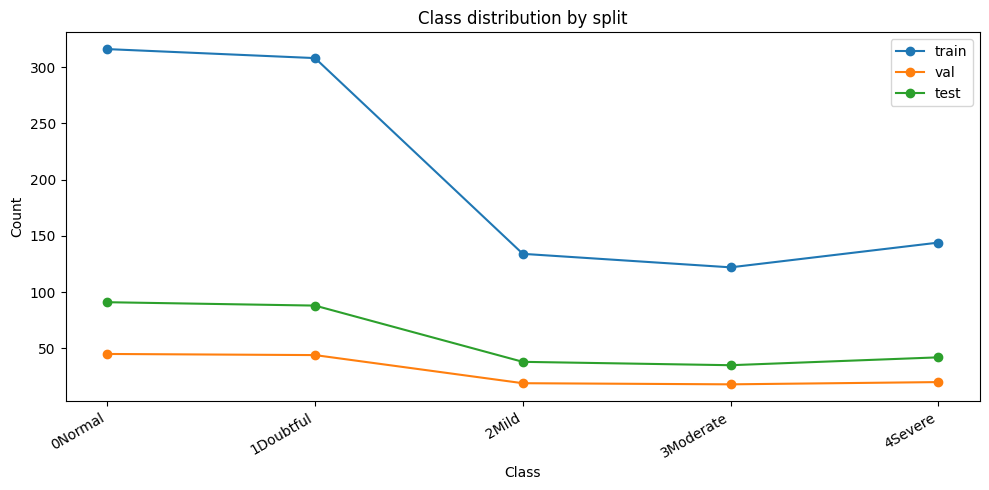

In [60]:
def dataset_distribution(dataset, split_name):
    counts = np.bincount(dataset.targets, minlength=len(dataset.classes))
    return pd.DataFrame({
        "split": split_name,
        "class_idx": list(range(len(dataset.classes))),
        "class_name": dataset.classes,
        "count": counts,
        "percentage": counts / counts.sum()
    })

dist_df = pd.concat([
    dataset_distribution(train_dataset, "train"),
    dataset_distribution(val_dataset, "val"),
    dataset_distribution(test_dataset, "test"),
], ignore_index=True)

display(dist_df)

plt.figure(figsize=(10, 5))
for split in ["train", "val", "test"]:
    temp = dist_df[dist_df["split"] == split]
    plt.plot(temp["class_name"], temp["count"], marker="o", label=split)

plt.title("Class distribution by split")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Visualization

This section shows:
- original images
- transformed baseline images after resize + normalization

No augmentation, CLAHE, or 4-crop is applied in this baseline.


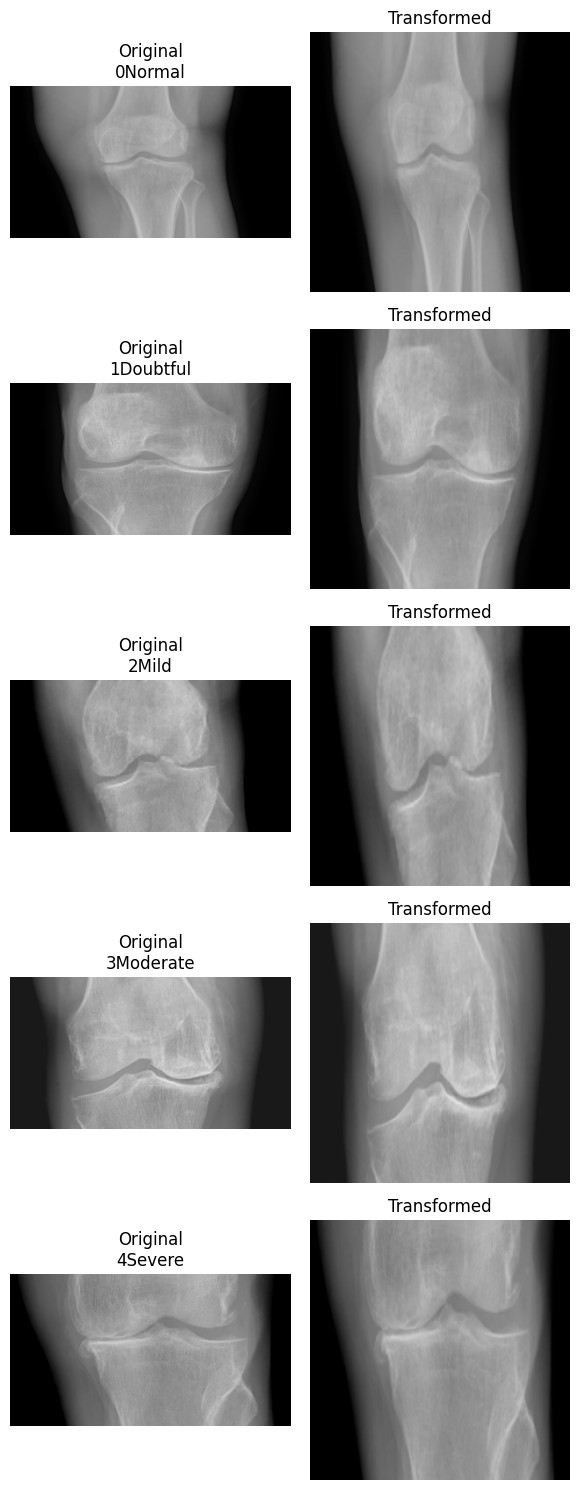

In [61]:
from PIL import Image

def denormalize_tensor(img_tensor, mean=None, std=None):
    if mean is None:
        mean = CONFIG["MEAN"]
    if std is None:
        std = CONFIG["STD"]

    img = img_tensor.detach().cpu().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    img = img * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

def show_original_and_transformed(dataset, n_per_class=2):
    samples_by_class = {i: [] for i in range(len(dataset.classes))}

    for path, label in dataset.samples:
        samples_by_class[label].append(path)

    rows = len(dataset.classes)
    cols = n_per_class * 2
    plt.figure(figsize=(cols * 3, rows * 3))

    plot_idx = 1
    for class_idx, class_name in enumerate(dataset.classes):
        chosen = random.sample(samples_by_class[class_idx], min(n_per_class, len(samples_by_class[class_idx])))

        for path in chosen:
            original = Image.open(path).convert("RGB")
            transformed = baseline_transform(original)

            plt.subplot(rows, cols, plot_idx)
            plt.imshow(original, cmap="gray")
            plt.title(f"Original\n{class_name}")
            plt.axis("off")
            plot_idx += 1

            plt.subplot(rows, cols, plot_idx)
            plt.imshow(denormalize_tensor(transformed))
            plt.title("Transformed")
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.show()

show_original_and_transformed(train_dataset, n_per_class=1)


## 8. Model Definition

Baseline model:
- single full image input
- DenseNet121 backbone
- one linear classifier head for 5-class grading


In [62]:
def build_densenet121(num_classes):
    try:
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)
        print("Loaded DenseNet121 with DEFAULT pretrained weights.")
    except Exception as e:
        print("Fallback to pretrained=True because DEFAULT weights are unavailable:", e)
        model = models.densenet121(pretrained=True)

    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)

    return model

model = build_densenet121(num_classes=num_classes).to(device)
print(model.classifier)


Loaded DenseNet121 with DEFAULT pretrained weights.
Linear(in_features=1024, out_features=5, bias=True)


## 9. Loss Function

Baseline loss: **CrossEntropyLoss**.

This baseline does not use ordinal-aware loss. Later experiments can compare against HybridOrdinalLoss.


In [63]:
criterion = nn.CrossEntropyLoss()
print("Criterion:", criterion)


Criterion: CrossEntropyLoss()


## 10. Optimizer & Scheduler

In [64]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["LR"],
    weight_decay=CONFIG["WEIGHT_DECAY"],
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG["EPOCHS"]
)

print("Optimizer:", optimizer)
print("Scheduler:", scheduler)


Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0001
    lr: 0.0001
    maximize: False
    weight_decay: 0.0
)
Scheduler: <torch.optim.lr_scheduler.CosineAnnealingLR object at 0x7adb143c0920>


## 11. Training Loop

In [65]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    mae = np.mean(np.abs(y_true - y_pred))

    diff = np.abs(y_true - y_pred)
    adjacent_errors = int(np.sum(diff == 1))
    distant_errors = int(np.sum(diff >= 2))
    total_errors = int(np.sum(diff > 0))

    return {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "qwk": float(qwk),
        "mae": float(mae),
        "total_errors": total_errors,
        "adjacent_errors": adjacent_errors,
        "distant_errors": distant_errors,
    }

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    all_true = []
    all_pred = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        all_true.extend(labels.detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_true, all_pred)
    metrics["loss"] = float(epoch_loss)

    return metrics

def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_true = []
    all_pred = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)

            running_loss += loss.item() * labels.size(0)

            preds = logits.argmax(dim=1)
            all_true.extend(labels.detach().cpu().numpy())
            all_pred.extend(preds.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_true, all_pred)
    metrics["loss"] = float(epoch_loss)

    return metrics, np.array(all_true), np.array(all_pred), np.array(all_probs)


In [66]:
history = []

best_val_qwk = -1.0
best_epoch = -1
patience_counter = 0

start_time = time.time()

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
    val_metrics, _, _, _ = evaluate(model, val_loader, criterion)

    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "train_mae": train_metrics["mae"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "val_qwk": val_metrics["qwk"],
        "val_mae": val_metrics["mae"],
        "val_adjacent_errors": val_metrics["adjacent_errors"],
        "val_distant_errors": val_metrics["distant_errors"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{CONFIG['EPOCHS']} | "
        f"train loss {train_metrics['loss']:.4f} acc {train_metrics['accuracy']:.4f} qwk {train_metrics['qwk']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.4f} qwk {val_metrics['qwk']:.4f} mae {val_metrics['mae']:.4f}"
    )

    if val_metrics["qwk"] > best_val_qwk:
        best_val_qwk = val_metrics["qwk"]
        best_epoch = epoch
        patience_counter = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "config": CONFIG,
            "class_names": class_names,
            "best_epoch": best_epoch,
            "best_val_qwk": best_val_qwk,
        }, MODEL_PATH)

        print(f"  Saved best model: epoch={best_epoch}, val_qwk={best_val_qwk:.6f}")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience {patience_counter}/{CONFIG['PATIENCE']}")

    if patience_counter >= CONFIG["PATIENCE"]:
        print("Early stopping triggered.")
        break

elapsed = time.time() - start_time
print(f"Training finished in {elapsed/60:.2f} minutes.")
print("Best epoch:", best_epoch)
print("Best val QWK:", best_val_qwk)

history_df = pd.DataFrame(history)
display(history_df.tail())
history_df.to_csv(HISTORY_PATH, index=False)
print("Saved history to:", HISTORY_PATH)


Epoch 01/30 | train loss 1.0926 acc 0.5791 qwk 0.6494 | val loss 0.7411 acc 0.7192 qwk 0.8338 mae 0.3836
  Saved best model: epoch=1, val_qwk=0.833808
Epoch 02/30 | train loss 0.5895 acc 0.8086 qwk 0.8875 | val loss 0.7411 acc 0.6986 qwk 0.8288 mae 0.3973
  No improvement. Patience 1/7
Epoch 03/30 | train loss 0.2998 acc 0.9219 qwk 0.9621 | val loss 0.5383 acc 0.8151 qwk 0.8856 mae 0.2603
  Saved best model: epoch=3, val_qwk=0.885558
Epoch 04/30 | train loss 0.2042 acc 0.9443 qwk 0.9603 | val loss 0.6115 acc 0.7945 qwk 0.8588 mae 0.3014
  No improvement. Patience 1/7
Epoch 05/30 | train loss 0.1201 acc 0.9717 qwk 0.9877 | val loss 0.6041 acc 0.7877 qwk 0.8962 mae 0.2671
  Saved best model: epoch=5, val_qwk=0.896249
Epoch 06/30 | train loss 0.0822 acc 0.9834 qwk 0.9930 | val loss 0.6146 acc 0.8151 qwk 0.8709 mae 0.2808
  No improvement. Patience 1/7
Epoch 07/30 | train loss 0.0779 acc 0.9795 qwk 0.9872 | val loss 0.8261 acc 0.7534 qwk 0.8799 mae 0.3151
  No improvement. Patience 2/7
Epo

,epoch,train_loss,train_accuracy,train_macro_f1,train_qwk,train_mae,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_qwk,val_mae,val_adjacent_errors,val_distant_errors
7,8,0.074096,0.977539,0.982120,0.993502,0.023438,0.966175,0.753425,0.727602,0.744331,0.858059,0.328767,28,8
8,9,0.073543,0.983398,0.984271,0.994987,0.017578,0.610164,0.808219,0.779456,0.802855,0.895097,0.253425,21,7
9,10,0.060873,0.984375,0.983492,0.990998,0.021484,0.671818,0.773973,0.728327,0.758844,0.871741,0.308219,24,9
10,11,0.045852,0.988281,0.987908,0.994979,0.013672,0.831873,0.760274,0.721867,0.739393,0.887273,0.308219,27,8
11,12,0.054719,0.988281,0.988643,0.997002,0.011719,0.810181,0.773973,0.768108,0.771168,0.873414,0.294521,26,7


Saved history to: /kaggle/working/baseline_single_image_densenet121_ce_no_aug/training_history.csv


## 12. Validation Section

In [67]:
# Load best checkpoint before validation/test reporting
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

val_metrics, val_true, val_pred, val_probs = evaluate(model, val_loader, criterion)

print("Best checkpoint validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v}")

print("\nValidation classification report:")
print(classification_report(val_true, val_pred, target_names=class_names, zero_division=0))


Best checkpoint validation metrics:
accuracy: 0.7876712328767124
macro_f1: 0.7574254571211976
weighted_f1: 0.7785104902383794
qwk: 0.8962493676679595
mae: 0.2671232876712329
total_errors: 31
adjacent_errors: 25
distant_errors: 6
loss: 0.6041161580751203

Validation classification report:
              precision    recall  f1-score   support

     0Normal       0.91      0.87      0.89        45
   1Doubtful       0.67      0.84      0.75        44
       2Mild       0.60      0.32      0.41        19
   3Moderate       0.94      0.83      0.88        18
     4Severe       0.82      0.90      0.86        20

    accuracy                           0.79       146
   macro avg       0.79      0.75      0.76       146
weighted avg       0.79      0.79      0.78       146



## 13. Test Evaluation

In [68]:
test_metrics, test_true, test_pred, test_probs = evaluate(model, test_loader, criterion)

print("Test metrics")
print("-" * 60)
for k, v in test_metrics.items():
    print(f"{k}: {v}")

print("\nTest classification report:")
print(classification_report(test_true, test_pred, target_names=class_names, zero_division=0))


Test metrics
------------------------------------------------------------
accuracy: 0.7619047619047619
macro_f1: 0.7433969130793148
weighted_f1: 0.7593760240953242
qwk: 0.8301311876220191
mae: 0.3469387755102041
total_errors: 70
adjacent_errors: 49
distant_errors: 21
loss: 0.6809557388935771

Test classification report:
              precision    recall  f1-score   support

     0Normal       0.84      0.80      0.82        91
   1Doubtful       0.71      0.82      0.76        88
       2Mild       0.63      0.50      0.56        38
   3Moderate       0.77      0.86      0.81        35
     4Severe       0.83      0.71      0.77        42

    accuracy                           0.76       294
   macro avg       0.76      0.74      0.74       294
weighted avg       0.76      0.76      0.76       294



## 13.1 Per-class Recall and F1

In [69]:
report_dict = classification_report(
    test_true,
    test_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class_rows = []
for class_name in class_names:
    per_class_rows.append({
        "class_name": class_name,
        "precision": report_dict[class_name]["precision"],
        "recall": report_dict[class_name]["recall"],
        "f1_score": report_dict[class_name]["f1-score"],
        "support": report_dict[class_name]["support"],
    })

per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df)


,class_name,precision,recall,f1_score,support
0,0Normal,0.839080,0.802198,0.820225,91.0
1,1Doubtful,0.705882,0.818182,0.757895,88.0
2,2Mild,0.633333,0.500000,0.558824,38.0
3,3Moderate,0.769231,0.857143,0.810811,35.0
4,4Severe,0.833333,0.714286,0.769231,42.0


## 14. Confusion Matrix

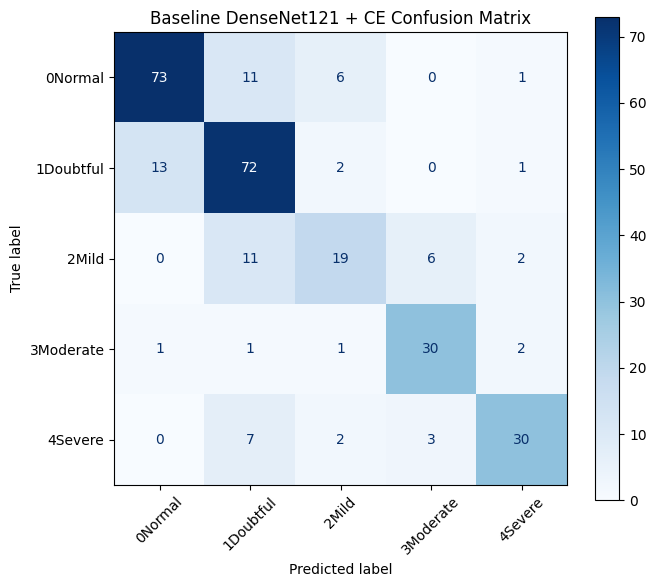

Saved confusion matrix to: /kaggle/working/baseline_single_image_densenet121_ce_no_aug/confusion_matrix.png


In [70]:
cm = confusion_matrix(test_true, test_pred, labels=list(range(num_classes)))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Baseline DenseNet121 + CE Confusion Matrix")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=200)
plt.show()

print("Saved confusion matrix to:", CONFUSION_MATRIX_PATH)


## 15. Error Analysis

Because OA severity is ordinal, adjacent errors are less severe than distant errors.


In [71]:
error_df = pd.DataFrame({
    "index": np.arange(len(test_true)),
    "true": test_true,
    "pred": test_pred,
})

error_df["true_name"] = [class_names[i] for i in error_df["true"]]
error_df["pred_name"] = [class_names[i] for i in error_df["pred"]]
error_df["error_distance"] = np.abs(error_df["true"] - error_df["pred"])
error_df["is_correct"] = error_df["error_distance"] == 0
error_df["is_adjacent_error"] = error_df["error_distance"] == 1
error_df["is_distant_error"] = error_df["error_distance"] >= 2

display(error_df["error_distance"].value_counts().sort_index().rename("count").to_frame())

print("Correct:", int(error_df["is_correct"].sum()))
print("Total errors:", int((~error_df["is_correct"]).sum()))
print("Adjacent errors:", int(error_df["is_adjacent_error"].sum()))
print("Distant errors:", int(error_df["is_distant_error"].sum()))

display(error_df[~error_df["is_correct"]].head(20))


,count
error_distance,
0,224
1,49
2,11
3,9
4,1


Correct: 224
Total errors: 70
Adjacent errors: 49
Distant errors: 21


,index,true,pred,true_name,pred_name,error_distance,is_correct,is_adjacent_error,is_distant_error
2,2,0,1,0Normal,1Doubtful,1,False,True,False
5,5,0,1,0Normal,1Doubtful,1,False,True,False
6,6,0,1,0Normal,1Doubtful,1,False,True,False
8,8,0,1,0Normal,1Doubtful,1,False,True,False
10,10,0,1,0Normal,1Doubtful,1,False,True,False
22,22,0,1,0Normal,1Doubtful,1,False,True,False
23,23,0,2,0Normal,2Mild,2,False,False,True
26,26,0,2,0Normal,2Mild,2,False,False,True
30,30,0,1,0Normal,1Doubtful,1,False,True,False
51,51,0,2,0Normal,2Mild,2,False,False,True


wrong samples: 70 / 294


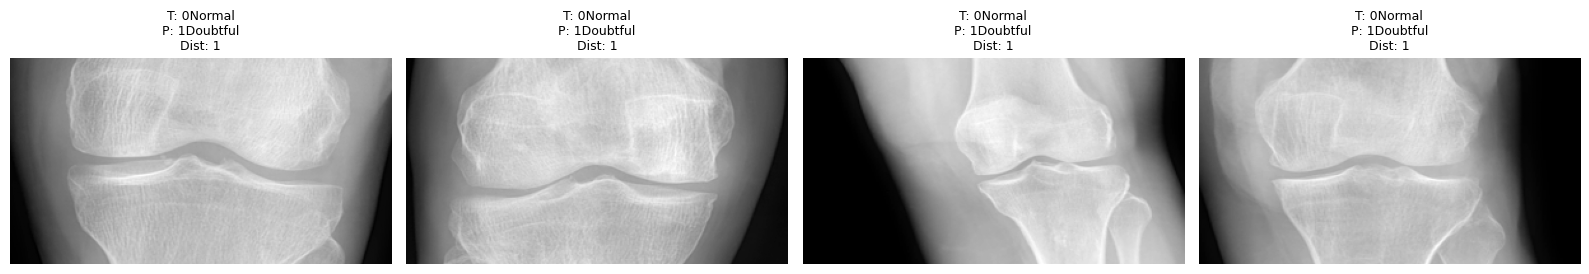

In [72]:
from PIL import Image
import math
import matplotlib.pyplot as plt

def show_misclassified_original_images(test_dataset, y_true, y_pred, class_names, max_images=12):
    wrong_indices = [
        i for i, (t, p) in enumerate(zip(y_true, y_pred))
        if int(t) != int(p)
    ]

    print(f"wrong samples: {len(wrong_indices)} / {len(y_true)}")

    show_indices = wrong_indices[:max_images]

    cols = 4
    rows = math.ceil(len(show_indices) / cols)

    plt.figure(figsize=(cols * 4, rows * 3.2))

    for plot_i, idx in enumerate(show_indices, start=1):
        # 关键：这里只用 samples 里的 path，不用 test_dataset[idx]
        img_path, true_label = test_dataset.samples[idx]
        pred_label = int(y_pred[idx])

        img = Image.open(img_path).convert("L")  # 原始灰度图
        dist = abs(int(true_label) - int(pred_label))

        plt.subplot(rows, cols, plot_i)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(
            f"T: {class_names[int(true_label)]}\n"
            f"P: {class_names[pred_label]}\n"
            f"Dist: {dist}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

show_misclassified_original_images(
    test_dataset=test_dataset,
    y_true=test_true,
    y_pred=test_pred,
    class_names=class_names,
    max_images=4
)

## 16. Grad-CAM

Grad-CAM is used only for explanation and error analysis. It is not an improvement method in this baseline.


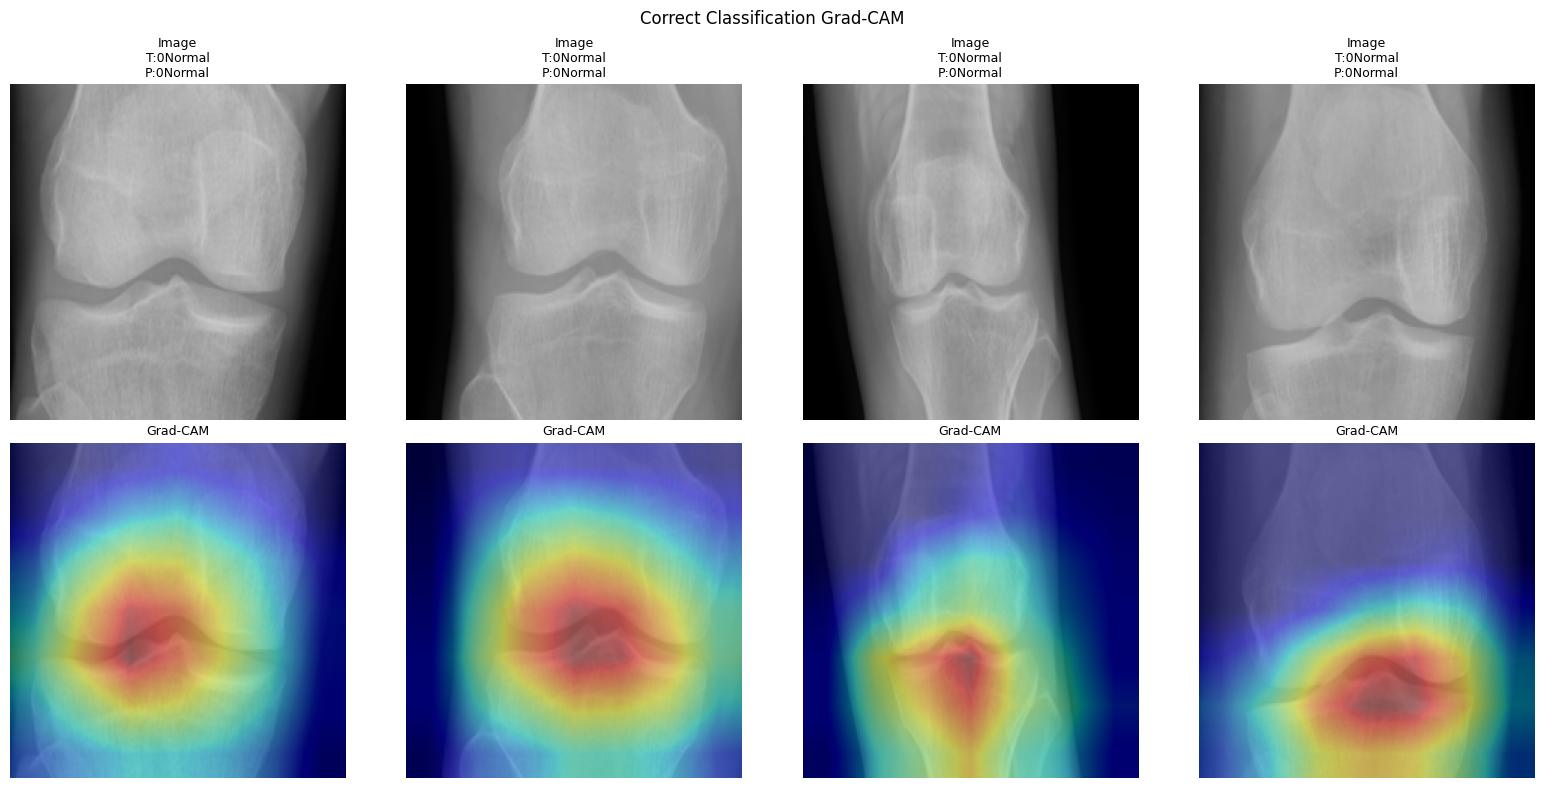

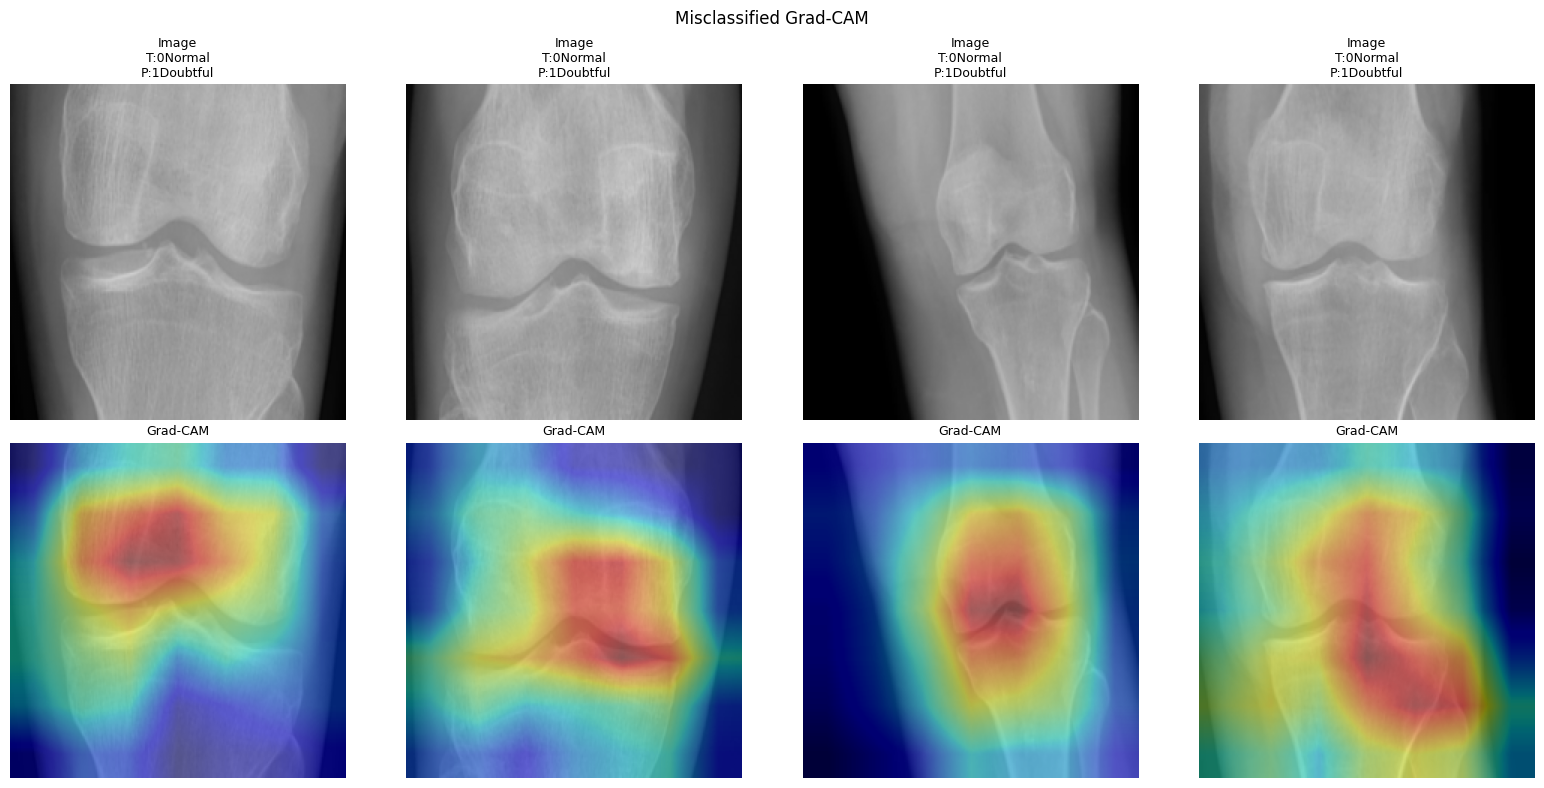

In [73]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        logits = self.model(input_tensor)

        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        score = logits[:, class_idx].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)

        cam = torch.nn.functional.interpolate(
            cam.unsqueeze(1),
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        ).squeeze(1)

        cam_min = cam.min()
        cam_max = cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam[0].detach().cpu().numpy(), logits.detach()

def show_gradcam_for_indices(model, dataset, indices, y_true, y_pred, title_prefix="Grad-CAM"):
    if len(indices) == 0:
        print("No indices to show.")
        return

    target_layer = model.features.denseblock4
    gradcam = GradCAM(model, target_layer)

    n = min(len(indices), 4)
    plt.figure(figsize=(n * 4, 8))

    for j, idx in enumerate(indices[:n]):
        img_path, label = dataset.samples[idx]
        img = Image.open(img_path).convert("RGB")

        input_tensor = val_transform(img).unsqueeze(0).to(device)

        cam, logits = gradcam(input_tensor, class_idx=int(y_pred[idx]))
        img_np = denormalize_tensor(input_tensor[0])

        plt.subplot(2, n, j + 1)
        plt.imshow(img_np)
        plt.axis("off")
        plt.title(f"Image\nT:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}", fontsize=9)

        plt.subplot(2, n, n + j + 1)
        plt.imshow(img_np)
        plt.imshow(cam, cmap="jet", alpha=0.45)
        plt.axis("off")
        plt.title("Grad-CAM", fontsize=9)

    plt.suptitle(title_prefix)
    plt.tight_layout()
    plt.show()

    gradcam.remove_hooks()

correct_indices = [i for i, (t, p) in enumerate(zip(test_true, test_pred)) if t == p]
wrong_indices = [i for i, (t, p) in enumerate(zip(test_true, test_pred)) if t != p]

show_gradcam_for_indices(model, test_dataset, correct_indices[:4], test_true, test_pred, title_prefix="Correct Classification Grad-CAM")
show_gradcam_for_indices(model, test_dataset, wrong_indices[:4], test_true, test_pred, title_prefix="Misclassified Grad-CAM")


## 17. Final Summary

This baseline uses a single full image DenseNet121 with CrossEntropyLoss. It provides the reference point for later improvements such as:
- data augmentation
- class balancing
- Hybrid Ordinal Loss
- 4-crop multi-region input
- CS-MHC hyperparameter tuning
- GLCM feature fusion
- ensemble learning


In [74]:
summary = {
    "experiment_name": CONFIG["EXPERIMENT_NAME"],
    "model": CONFIG["MODEL_NAME"],
    "loss": CONFIG["LOSS"],
    "data_augmentation": False,
    "clahe_training": False,
    "multi_crop": False,
    "class_balancing": False,
    "best_epoch": int(best_epoch),
    "best_val_qwk": float(best_val_qwk),
    "test_metrics": test_metrics,
    "per_class_metrics": per_class_df.to_dict(orient="records"),
    "config": CONFIG,
}

print(json.dumps(summary, indent=2))


{
  "experiment_name": "baseline_single_image_densenet121_ce_no_aug",
  "model": "DenseNet121",
  "loss": "CrossEntropyLoss",
  "data_augmentation": false,
  "clahe_training": false,
  "multi_crop": false,
  "class_balancing": false,
  "best_epoch": 5,
  "best_val_qwk": 0.8962493676679595,
  "test_metrics": {
    "accuracy": 0.7619047619047619,
    "macro_f1": 0.7433969130793148,
    "weighted_f1": 0.7593760240953242,
    "qwk": 0.8301311876220191,
    "mae": 0.3469387755102041,
    "total_errors": 70,
    "adjacent_errors": 49,
    "distant_errors": 21,
    "loss": 0.6809557388935771
  },
  "per_class_metrics": [
    {
      "class_name": "0Normal",
      "precision": 0.8390804597701149,
      "recall": 0.8021978021978022,
      "f1_score": 0.8202247191011236,
      "support": 91.0
    },
    {
      "class_name": "1Doubtful",
      "precision": 0.7058823529411765,
      "recall": 0.8181818181818182,
      "f1_score": 0.7578947368421053,
      "support": 88.0
    },
    {
      "class

## 18. Save Results

In [75]:
with open(METRICS_PATH, "w") as f:
    json.dump({
        "test_metrics": test_metrics,
        "per_class_metrics": per_class_df.to_dict(orient="records"),
        "classification_report": report_dict,
    }, f, indent=2)

with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2)

error_df.to_csv(OUTPUT_DIR / "error_analysis.csv", index=False)
per_class_df.to_csv(OUTPUT_DIR / "per_class_metrics.csv", index=False)

print("Saved files:")
print(" -", METRICS_PATH)
print(" -", SUMMARY_PATH)
print(" -", HISTORY_PATH)
print(" -", CONFUSION_MATRIX_PATH)
print(" -", OUTPUT_DIR / "error_analysis.csv")
print(" -", OUTPUT_DIR / "per_class_metrics.csv")


Saved files:
 - /kaggle/working/baseline_single_image_densenet121_ce_no_aug/metrics.json
 - /kaggle/working/baseline_single_image_densenet121_ce_no_aug/summary.json
 - /kaggle/working/baseline_single_image_densenet121_ce_no_aug/training_history.csv
 - /kaggle/working/baseline_single_image_densenet121_ce_no_aug/confusion_matrix.png
 - /kaggle/working/baseline_single_image_densenet121_ce_no_aug/error_analysis.csv
 - /kaggle/working/baseline_single_image_densenet121_ce_no_aug/per_class_metrics.csv
